# Logistic Regression: Section 1 Likelihood Experiments (ESS vs MESS)

This notebook reproduces and extends the Section 1 logistic-regression likelihood experiment.

Outputs include:
- Shrinking steps vs M
- Likelihood evaluations vs M (serial and per-core proxy)
- Log-likelihood ESS vs M

Chain reuse policy:
- Looks for existing cached chains in mess-internal and mcmc-internal estimations.
- Prints explicit warnings when chain families are missing locally.
- Can optionally run missing chains and cache them.

In [1]:
import os
import sys
import json
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

def find_workspace_root(start: Path) -> Path:
    start = start.resolve()
    for cand in [start] + list(start.parents):
        if (cand / 'mcmc-internal').exists() and (cand / 'mess-internal').exists():
            return cand
    return start

def resolve_repo_root(start: Path) -> Path:
    cur = start.resolve()
    while cur != cur.parent and not (cur / 'pyproject.toml').exists():
        cur = cur.parent
    return cur

cwd = Path.cwd().resolve()
repo_root = resolve_repo_root(cwd)
workspace_root = find_workspace_root(repo_root)
mess_internal_root = workspace_root / 'mess-internal'
mcmc_internal_root = workspace_root / 'mcmc-internal'

for src in [mess_internal_root / 'src', mcmc_internal_root / 'src']:
    if src.exists() and str(src) not in sys.path:
        sys.path.insert(0, str(src))

from mess.algorithms.ess import ess_step
from mess.algorithms.mess import mess_step
from mess.algorithms.effective_sample_size import estimate_effective_sample_size
from mess.problems.logistic_regression import BayesianLogisticRegression
from mess.data.logistic_regression import generate_logistic_regression_data

print('workspace_root:', workspace_root)
print('mess_internal_root exists:', mess_internal_root.exists())
print('mcmc_internal_root exists:', mcmc_internal_root.exists())

workspace_root: /Users/guillers/Documents/GitHub/mcmc
mess_internal_root exists: True
mcmc_internal_root exists: True


In [2]:
# Experiment configuration
seed_data = 123
seed_mcmc = 0
n_samples = 1000
n_features = 200
noise_scale = 0.0
prior_var = 1.0

M_values = [1, 2, 5, 10, 20, 50, 100]
n_iters = 10000
burn_in = 2000
max_lag = 1500
parallel_workers_proxy = 12

# If True, run missing chains and cache them.
run_missing_chains = True

run_tag = f'logreg_n{n_samples}_p{n_features}_iters{n_iters}_seed{seed_data}'
cache_dir = mess_internal_root / 'estimations' / 'jcgs_logistic_section1' / run_tag
report_dir = mess_internal_root / 'reports' / 'jcgs-notebooks' / 'logistic_section1' / run_tag
cache_dir.mkdir(parents=True, exist_ok=True)
report_dir.mkdir(parents=True, exist_ok=True)

print('run_tag:', run_tag)
print('cache_dir:', cache_dir)
print('report_dir:', report_dir)

run_tag: logreg_n1000_p200_iters10000_seed123
cache_dir: /Users/guillers/Documents/GitHub/mcmc/mess-internal/estimations/jcgs_logistic_section1/logreg_n1000_p200_iters10000_seed123
report_dir: /Users/guillers/Documents/GitHub/mcmc/mess-internal/reports/jcgs-notebooks/logistic_section1/logreg_n1000_p200_iters10000_seed123


In [3]:
# Data and problem setup
data = generate_logistic_regression_data(
    n_samples=n_samples,
    n_features=n_features,
    beta_true=None,
    noise_scale=noise_scale,
    seed=seed_data,
)
X = data['X']
y = data['y']
beta_true = data['beta_true']

problem = BayesianLogisticRegression(X, y, prior_var=prior_var)
beta0 = np.zeros(n_features)

print('X shape:', X.shape)
print('y mean:', float(np.mean(y)))
print('Initial log-likelihood:', float(problem.log_likelihood(beta0)))

X shape: (1000, 200)
y mean: 0.512
Initial log-likelihood: -693.1471805599454


In [4]:
# Chain cache helpers and local chain discovery warnings
warnings = []

def add_warning(msg):
    warnings.append(msg)
    print('WARNING:', msg)

def chain_file(method, M):
    return cache_dir / f'{method}_M{M}.npz'

def save_chain_bundle(path, chain, intervals, runtime_sec):
    np.savez_compressed(
        path,
        chain=np.asarray(chain, dtype=float),
        intervals=np.asarray(intervals, dtype=float),
        runtime_sec=float(runtime_sec),
    )

def load_chain_bundle(path):
    with np.load(path, allow_pickle=False) as npz:
        return {
            'chain': np.asarray(npz['chain'], dtype=float),
            'intervals': np.asarray(npz['intervals'], dtype=float),
            'runtime_sec': float(npz['runtime_sec']),
        }

# Check whether legacy logistic outputs exist in existing estimations trees.
legacy_mess = sorted((mess_internal_root / 'estimations').glob('**/*log*reg*'))
legacy_mcmc = sorted((mcmc_internal_root / 'estimations').glob('**/*log*reg*'))
if not legacy_mess:
    add_warning('No obvious legacy logistic-regression estimation directories found under mess-internal/estimations.')
if not legacy_mcmc:
    add_warning('No obvious legacy logistic-regression estimation directories found under mcmc-internal/estimations.')

print('legacy logistic dirs (mess-internal):', len(legacy_mess))
print('legacy logistic dirs (mcmc-internal):', len(legacy_mcmc))

legacy logistic dirs (mess-internal): 1
legacy logistic dirs (mcmc-internal): 0


In [5]:
# Run or load chains for ESS/MESS uniform
results = {}

for M in M_values:
    method = 'mess_uniform'
    path = chain_file(method, M)

    if path.exists():
        bundle = load_chain_bundle(path)
        results[M] = bundle
        print(f'Loaded cached chain for M={M}: {path.name}')
        continue

    add_warning(f'Missing local chain for M={M} at {path}.')
    if not run_missing_chains:
        continue

    rng = np.random.default_rng(seed_mcmc + M)
    x = beta0.copy()
    chain = np.zeros((n_iters, n_features), dtype=float)
    intervals = np.zeros(n_iters, dtype=float)

    t0 = time.perf_counter()
    for t in range(n_iters):
        x, nr_intervals, _ = mess_step(x, problem, rng, M=M, use_lp=False)
        chain[t] = x
        intervals[t] = nr_intervals
    runtime_sec = time.perf_counter() - t0

    bundle = {'chain': chain, 'intervals': intervals, 'runtime_sec': runtime_sec}
    results[M] = bundle
    save_chain_bundle(path, chain, intervals, runtime_sec)
    print(f'Computed and cached M={M} in {runtime_sec:.2f}s')

print('Available M values:', sorted(results.keys()))

Computed and cached M=1 in 8.96s
Computed and cached M=2 in 42.90s
Computed and cached M=5 in 55.84s
Computed and cached M=10 in 84.67s
Computed and cached M=20 in 126.22s
Computed and cached M=50 in 252.33s
Computed and cached M=100 in 445.58s
Available M values: [1, 2, 5, 10, 20, 50, 100]


In [6]:
if not results:
    raise ValueError('No chains are available to analyze. Enable run_missing_chains or provide cached chains.')

summary = []
for M in sorted(results):
    chain = results[M]['chain']
    intervals = results[M]['intervals']
    runtime_sec = results[M]['runtime_sec']

    post = chain[burn_in:]
    ll = np.asarray([problem.log_likelihood(x) for x in post], dtype=float)
    ll_ess = float(estimate_effective_sample_size(ll.reshape(-1, 1), max_lag=max_lag)[0]) if len(ll) > 2 else np.nan

    mean_shrinks = float(np.mean(intervals + 1.0))
    mean_lik_serial = float(np.mean((intervals + 1.0) * M))
    mean_lik_parallel_proxy = float(np.mean((intervals + 1.0) * np.ceil(M / max(1, parallel_workers_proxy))))

    summary.append({
        'M': M,
        'runtime_sec': runtime_sec,
        'mean_shrinking_steps': mean_shrinks,
        'mean_lik_serial': mean_lik_serial,
        'mean_lik_parallel_proxy': mean_lik_parallel_proxy,
        'loglik_ess': ll_ess,
    })

summary = sorted(summary, key=lambda d: d['M'])
print('Summary rows:', len(summary))
for row in summary:
    print(row)

Estimating ESS for each parameter.
Estimating ESS for each parameter.
Estimating ESS for each parameter.
Estimating ESS for each parameter.
Estimating ESS for each parameter.
Estimating ESS for each parameter.
Estimating ESS for each parameter.
Summary rows: 7
{'M': 1, 'runtime_sec': 8.958235457999763, 'mean_shrinking_steps': 9.6777, 'mean_lik_serial': 9.6777, 'mean_lik_parallel_proxy': 9.6777, 'loglik_ess': 7.901709700935768}
{'M': 2, 'runtime_sec': 42.90014370799963, 'mean_shrinking_steps': 6.0064, 'mean_lik_serial': 12.0128, 'mean_lik_parallel_proxy': 6.0064, 'loglik_ess': 6.610261721894066}
{'M': 5, 'runtime_sec': 55.84000170899981, 'mean_shrinking_steps': 3.6378, 'mean_lik_serial': 18.189, 'mean_lik_parallel_proxy': 3.6378, 'loglik_ess': 7.476684860371487}
{'M': 10, 'runtime_sec': 84.6721667920001, 'mean_shrinking_steps': 2.7441, 'mean_lik_serial': 27.441, 'mean_lik_parallel_proxy': 2.7441, 'loglik_ess': 5.9503626416014415}
{'M': 20, 'runtime_sec': 126.22035041699928, 'mean_shrink

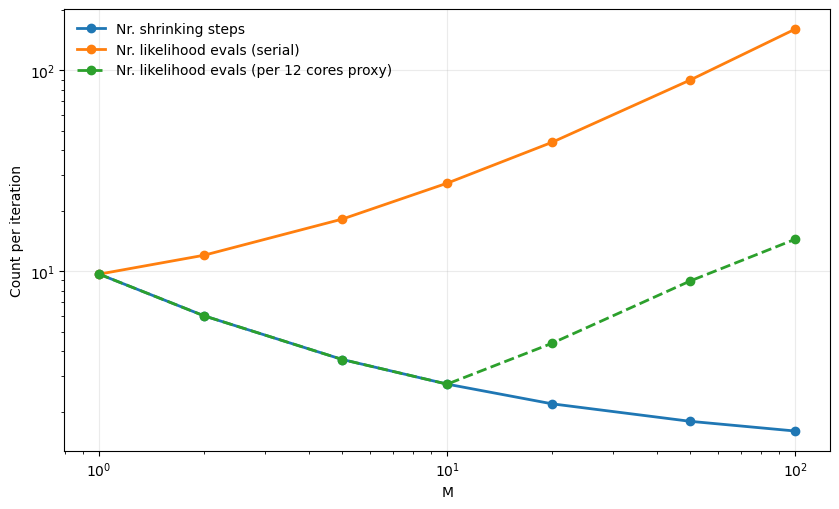

Saved: /Users/guillers/Documents/GitHub/mcmc/mess-internal/reports/jcgs-notebooks/logistic_section1/logreg_n1000_p200_iters10000_seed123/logreg_shrinking_vs_likelihood_evals_iters10000.png


In [7]:
# Plot 1: shrinking steps vs likelihood evaluations
M_plot = np.asarray([row['M'] for row in summary], dtype=float)
shrinks = np.asarray([row['mean_shrinking_steps'] for row in summary], dtype=float)
lik_serial = np.asarray([row['mean_lik_serial'] for row in summary], dtype=float)
lik_parallel = np.asarray([row['mean_lik_parallel_proxy'] for row in summary], dtype=float)

fig, ax = plt.subplots(1, 1, figsize=(8.5, 5.2))
ax.plot(M_plot, shrinks, marker='o', linewidth=2, label='Nr. shrinking steps')
ax.plot(M_plot, lik_serial, marker='o', linewidth=2, label='Nr. likelihood evals (serial)')
ax.plot(M_plot, lik_parallel, marker='o', linewidth=2, linestyle='--', label=f'Nr. likelihood evals (per {parallel_workers_proxy} cores proxy)')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('M')
ax.set_ylabel('Count per iteration')
ax.grid(alpha=0.25)
ax.legend(frameon=False)
fig.tight_layout()
fig1_path = report_dir / f'logreg_shrinking_vs_likelihood_evals_iters{n_iters}.png'
fig.savefig(fig1_path, dpi=300, bbox_inches='tight')
plt.show()
print('Saved:', fig1_path)

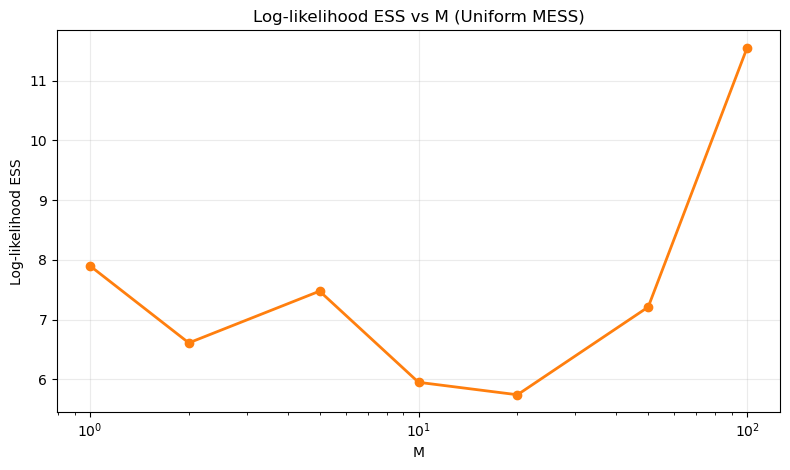

Saved: /Users/guillers/Documents/GitHub/mcmc/mess-internal/reports/jcgs-notebooks/logistic_section1/logreg_n1000_p200_iters10000_seed123/logreg_loglik_ess_vs_M_iters10000.png


In [8]:
# Plot 2: log-likelihood ESS vs M
ll_ess = np.asarray([row['loglik_ess'] for row in summary], dtype=float)

fig, ax = plt.subplots(1, 1, figsize=(8.0, 4.8))
ax.plot(M_plot, ll_ess, marker='o', linewidth=2, color='tab:orange')
ax.set_xscale('log')
ax.set_xlabel('M')
ax.set_ylabel('Log-likelihood ESS')
ax.set_title('Log-likelihood ESS vs M (Uniform MESS)')
ax.grid(alpha=0.25)
fig.tight_layout()
fig2_path = report_dir / f'logreg_loglik_ess_vs_M_iters{n_iters}.png'
fig.savefig(fig2_path, dpi=300, bbox_inches='tight')
plt.show()
print('Saved:', fig2_path)

In [9]:
# Save summary + warning report
summary_path = report_dir / 'logreg_likelihood_experiment_summary.json'
warning_path = report_dir / 'missing_chain_warnings.json'

with open(summary_path, 'w', encoding='utf-8') as f:
    json.dump(summary, f, indent=2)
with open(warning_path, 'w', encoding='utf-8') as f:
    json.dump({'warnings': warnings}, f, indent=2)

print('Saved summary:', summary_path)
print('Saved warnings:', warning_path)
if warnings:
    print('Some chain families were missing locally. See warning file.')
else:
    print('No missing-chain warnings.')

Saved summary: /Users/guillers/Documents/GitHub/mcmc/mess-internal/reports/jcgs-notebooks/logistic_section1/logreg_n1000_p200_iters10000_seed123/logreg_likelihood_experiment_summary.json
Saved warnings: /Users/guillers/Documents/GitHub/mcmc/mess-internal/reports/jcgs-notebooks/logistic_section1/logreg_n1000_p200_iters10000_seed123/missing_chain_warnings.json
Some chain families were missing locally. See warning file.
